# Modelagem Preditiva do Peso Médio de Frangos de Corte
### Consultoria de dados — Projeto Integrado: Negócios · PUC-SP
**Equipe:** Alexander Haug · Carlos Calil · Carlos Braga · Pedro Carvalho

Este notebook é o código que gera os resultados da apresentação. Cada seção corresponde a um slide.

**Como rodar:** coloque o arquivo `Base_Dados_Modelos_peso.xlsx` na mesma pasta deste notebook e execute as células na ordem (menu *Run > Run All*).

**Bibliotecas necessárias:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `openpyxl`
```
pip install pandas numpy scikit-learn matplotlib openpyxl
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# paleta para os gráficos (mesma da apresentação)
VERDE='#2D6A4F'; VERDE_CLARO='#95D5B2'; LARANJA='#E07A1F'; CINZA='#5B6B63'
plt.rcParams.update({'figure.dpi':110, 'font.size':11, 'axes.edgecolor':CINZA})

BASE_PATH = 'Base_Dados_Modelos_peso.xlsx'   # ajuste o caminho se necessário

## Slide 3 — A base de dados
Carregamos a base e olhamos o tamanho, as colunas e a variável-resposta (coluna AN = `Peso Médio (kg)`).

In [2]:
df = pd.read_excel(BASE_PATH)
ALVO = 'Peso Médio (kg)'      # coluna AN — o que queremos prever

print('Dimensão da base:', df.shape, '(linhas x colunas)')
print('\nVariável-resposta (Peso Médio kg):')
print(df[ALVO].describe()[['mean','min','max','std']].round(3))
df.head()

Dimensão da base: (5813, 40) (linhas x colunas)

Variável-resposta (Peso Médio kg):
mean    3.310
min     2.248
max     4.590
std     0.276
Name: Peso Médio (kg), dtype: float64


,Produtor,Regiao,Tecnico,Num_Galpao,Tipo_Instalacao,Nutricao,Área,Genetica,Origem,Peso Pintinho (kg),...,%Mort42,%Mort49,Ração Pré,RaçãoInicial,Ração Cres1,Ração Cres2,Ração Final,Ração Total,Sobra Racao,Peso Médio (kg)
0,P147,Regiao_1,Tecnico_1,3,Tipo_1,N_3,2508,G_1,Origem_15,0.046,...,2.906832,3.338509,6036,30004,22018,92009,22994,173061,13810,3.135152
1,P66,Regiao_1,Tecnico_1,1,Tipo_1,N_3,1500,G_1,Origem_5,0.038,...,2.870787,3.477528,3298,16888,12012,36077,33545,101820,7370,3.257123
2,P61,Regiao_2,Tecnico_2,2,Tipo_2,N_2,2100,G_1,Origem_20,0.042,...,7.308772,10.659649,6292,25993,18965,89987,21883,163120,1960,3.451424
3,P61,Regiao_2,Tecnico_2,5,Tipo_1,N_2,2400,G_1,Origem_5,0.041,...,3.214984,3.811075,6288,28998,21348,95224,35729,187587,2210,3.496485
4,P61,Regiao_2,Tecnico_2,7,Tipo_1,N_2,2400,G_1,Origem_5,0.043,...,4.325733,5.172638,6294,28991,21092,95907,32940,185224,0,3.534697


In [3]:
# Tipos e valores nulos por coluna
info = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'valores_unicos': df.nunique()
})
info

,tipo,nulos,valores_unicos
Produtor,str,0,333
Regiao,str,0,15
Tecnico,str,0,12
Num_Galpao,int64,0,10
Tipo_Instalacao,str,0,16
Nutricao,str,0,5
Área,int64,0,61
Genetica,str,0,5
Origem,str,0,22
Peso Pintinho (kg),float64,0,734


## Slide 4 — Diagnóstico de qualidade de dados
Antes de modelar, auditamos as variáveis. A base do cliente tinha **erros graves** que distorceriam qualquer análise.

In [4]:
# Erros grosseiros nos preditores numéricos
print('Peso do pintinho — máximo absurdo:', df['Peso Pintinho (kg)'].max(), 'kg  (mediana real:', round(df['Peso Pintinho (kg)'].median(),3), 'kg)')
print('Densidade — máximo absurdo:', df['Densidade (aves/m²)'].max(), 'aves/m2  (mediana:', round(df['Densidade (aves/m²)'].median(),1), ')')
print('Vazio (dias) — mínimo impossível:', df['Vazio (dias)'].min(), 'dias  (não existe vazio negativo)')

# Pesagens semanais: medianas coerentes, mas máximos em gramas (erro de unidade)
sem = ['Peso7','Peso14','Peso21','Peso28','Peso35','Peso42','Peso49']
print('\nPesagens semanais (mediana coerente, máximo em unidade trocada):')
print(df[sem].agg(['median','max']).round(2))

Peso do pintinho — máximo absurdo: 599391.0 kg  (mediana real: 0.044 kg)
Densidade — máximo absurdo: 1843.75 aves/m2  (mediana: 13.2 )
Vazio (dias) — mínimo impossível: -43.0 dias  (não existe vazio negativo)

Pesagens semanais (mediana coerente, máximo em unidade trocada):
         Peso7  Peso14  Peso21   Peso28   Peso35  Peso42  Peso49
median    0.18    0.48    0.95     1.52     2.18     2.8     2.9
max     185.00  450.00  984.00  1270.00  2314.00  3093.0  3520.0


## Slide 5 — Vazamento de dados (*data leakage*)
Algumas colunas **não preveem** o peso — elas **são** o peso disfarçado. `Peso Abatido ÷ Aves Abatidas` é idêntico ao alvo. Usá-las daria um R² falso de ~1. Por isso são excluídas.

In [5]:
conta = df['Peso Abatido (kg)'] / df['Aves Abatidas']
print('Correlação de (Peso Abatido / Aves Abatidas) com o alvo:', round(conta.corr(df[ALVO]), 4))
print('Diferença média absoluta:', round((conta - df[ALVO]).abs().mean(), 6), '(zero = é a mesma coisa)')

# Variáveis medidas no abate ou depois -> excluídas dos preditores
VAZAMENTO = ['Peso Abatido (kg)', 'Aves Abatidas', 'Idade Média (dias)', 'Data Abate',
             'Ração Pré','RaçãoInicial','Ração Cres1','Ração Cres2','Ração Final','Ração Total','Sobra Racao']
print('\nColunas excluídas por vazamento/desfecho:', len(VAZAMENTO))

Correlação de (Peso Abatido / Aves Abatidas) com o alvo: 1.0
Diferença média absoluta: 0.0 (zero = é a mesma coisa)

Colunas excluídas por vazamento/desfecho: 11


## Limpeza dos dados
Corrigimos a unidade das pesagens, removemos valores fisicamente impossíveis (viram nulo e são imputados pela mediana), tratamos o único nulo de `Vazio` e criamos o mês de alojamento.

In [6]:
df_limpo = df.copy()

# 1) Pesagens semanais: corrige gramas->kg e remove impossíveis
limites = {'Peso7':0.5,'Peso14':1.0,'Peso21':1.8,'Peso28':2.5,'Peso35':3.5,'Peso42':4.5,'Peso49':5.5}
for c in sem:
    s = df_limpo[c].astype(float).copy()
    s[s > limites[c]*5] = s[s > limites[c]*5] / 1000      # claramente em gramas
    s[(s > limites[c]) | (s == 0)] = np.nan               # resto: impossível -> nulo
    df_limpo[c] = s

# 2) Preditores numéricos: limites fisiológicos
faixas = {'Peso Pintinho (kg)':(0.025,0.09), 'Densidade (aves/m²)':(5,25),
          'Área':(200,None), 'Vazio (dias)':(0,120)}
corrigidos = {}
for c,(lo,hi) in faixas.items():
    s = df_limpo[c].astype(float).copy()
    ruim = s < lo
    if hi is not None: ruim = ruim | (s > hi)
    corrigidos[c] = int(ruim.sum())
    s[ruim] = np.nan
    df_limpo[c] = s

# 3) Único nulo de Vazio -> mediana ; 4) mês de alojamento (sazonalidade)
df_limpo['Vazio (dias)'] = df_limpo['Vazio (dias)'].fillna(df_limpo['Vazio (dias)'].median())
df_limpo['Mes'] = pd.to_datetime(df_limpo['Data Alojamento']).dt.month

print('Registros corrigidos por variável:', corrigidos)

Registros corrigidos por variável: {'Peso Pintinho (kg)': 200, 'Densidade (aves/m²)': 58, 'Área': 22, 'Vazio (dias)': 18}


## Slide 6 — Dummies e preparação
Variáveis de texto (região, genética, etc.) viram colunas 0/1 (*one-hot*). Categorias muito raras são agrupadas em "Outros" para estabilizar os modelos. Montamos dois cenários de preditores.

In [7]:
def agrupar_raras(s, minimo=0.01):
    s = s.astype(str)
    freq = s.value_counts(normalize=True)
    raras = freq[freq < minimo].index
    return s.where(~s.isin(raras), 'Outros')

CATEGORICAS = ['Regiao','Tecnico','Tipo_Instalacao','Nutricao','Genetica','Origem','Mes']
for c in CATEGORICAS:
    df_limpo[c] = agrupar_raras(df_limpo[c])

NUM_SETUP = ['Num_Galpao','Área','Peso Pintinho (kg)','Aves Alojadas','Densidade (aves/m²)','Vazio (dias)']
NUM_PRECOCE = ['Peso7','Peso14','Peso21','%Mort7','%Mort14','%Mort21']

def montar_X(numericas):
    Xcat = pd.get_dummies(df_limpo[CATEGORICAS], drop_first=True).astype(float)
    Xnum = df_limpo[numericas].copy()
    Xnum = Xnum.fillna(Xnum.median())
    return pd.concat([Xnum.reset_index(drop=True), Xcat.reset_index(drop=True)], axis=1)

y = df_limpo[ALVO].copy()
X_A = montar_X(NUM_SETUP)                 # Cenário A: só fatores de setup (ex-ante)
X_B = montar_X(NUM_SETUP + NUM_PRECOCE)   # Cenário B: setup + acompanhamento precoce

print('Cenário A (setup):', X_A.shape[1], 'colunas após dummies')
print('Cenário B (setup + precoce):', X_B.shape[1], 'colunas após dummies')
X_B.head(3)

Cenário A (setup): 67 colunas após dummies
Cenário B (setup + precoce): 73 colunas após dummies


,Num_Galpao,Área,Peso Pintinho (kg),Aves Alojadas,Densidade (aves/m²),Vazio (dias),Peso7,Peso14,Peso21,%Mort7,...,Mes_11,Mes_12,Mes_2,Mes_3,Mes_4,Mes_5,Mes_6,Mes_7,Mes_8,Mes_9
0,3,2508.0,0.046,32200,12.839,13.0,0.175,0.461,0.850,0.748447,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1500.0,0.038,17800,11.867,10.0,0.170,0.435,0.850,0.780899,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2100.0,0.042,28500,13.571,15.0,0.185,0.475,0.954,4.473684,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Slide 7 — Modelos e desempenho
Testamos 5 modelos em cada cenário. Separação treino/teste 80/20 e validação cruzada de 5 fatias. Medimos R², RMSE e MAE (em kg).

In [8]:
def avaliar(X, rotulo):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    kf = KFold(5, shuffle=True, random_state=42)
    modelos = {
        'Regressão Linear': Pipeline([('s',StandardScaler()), ('m',LinearRegression())]),
        'Ridge':            Pipeline([('s',StandardScaler()), ('m',RidgeCV(alphas=np.logspace(-1,4,40)))]),
        'Lasso':            Pipeline([('s',StandardScaler()), ('m',LassoCV(alphas=np.logspace(-3,1,30), max_iter=8000))]),
        'Random Forest':    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
        'Gradient Boosting':GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    }
    linhas = []
    ajustados = {}
    for nome, mdl in modelos.items():
        r2cv = cross_val_score(mdl, Xtr, ytr, cv=kf, scoring='r2').mean()
        mdl.fit(Xtr, ytr); pred = mdl.predict(Xte); ajustados[nome] = mdl
        linhas.append({'Cenário':rotulo, 'Modelo':nome,
                       'R2_CV':round(r2cv,3), 'R2_teste':round(r2_score(yte,pred),3),
                       'RMSE_kg':round(mean_squared_error(yte,pred)**0.5,3),
                       'MAE_kg':round(mean_absolute_error(yte,pred),3)})
    return pd.DataFrame(linhas), ajustados, (Xtr,Xte,ytr,yte)

res_A, mod_A, _      = avaliar(X_A, 'A: Setup')
res_B, mod_B, dados_B = avaliar(X_B, 'B: Setup + precoce')
resultados = pd.concat([res_A, res_B], ignore_index=True)
print('Baseline (chutar a média) — RMSE:', round(y.std(),3), 'kg')
resultados

Baseline (chutar a média) — RMSE: 0.276 kg


,Cenário,Modelo,R2_CV,R2_teste,RMSE_kg,MAE_kg
0,A: Setup,Regressão Linear,0.379,0.349,0.219,0.172
1,A: Setup,Ridge,0.379,0.349,0.219,0.172
2,A: Setup,Lasso,0.378,0.352,0.219,0.172
3,A: Setup,Random Forest,0.467,0.494,0.193,0.149
4,A: Setup,Gradient Boosting,0.408,0.416,0.208,0.163
5,B: Setup + precoce,Regressão Linear,0.396,0.363,0.217,0.171
6,B: Setup + precoce,Ridge,0.396,0.364,0.217,0.171
7,B: Setup + precoce,Lasso,0.395,0.365,0.216,0.170
8,B: Setup + precoce,Random Forest,0.454,0.485,0.195,0.152
9,B: Setup + precoce,Gradient Boosting,0.420,0.434,0.204,0.159


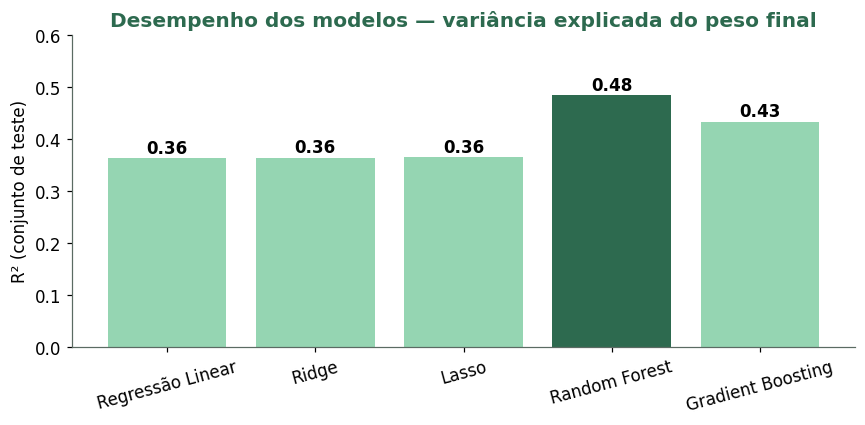

In [9]:
# Gráfico do slide 7: R2 de teste por modelo (cenário B)
plt.figure(figsize=(8,4))
sub = res_B.copy()
cores = [VERDE if v == sub['R2_teste'].max() else VERDE_CLARO for v in sub['R2_teste']]
plt.bar(sub['Modelo'], sub['R2_teste'], color=cores)
for i,v in enumerate(sub['R2_teste']): plt.text(i, v+0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.ylabel('R² (conjunto de teste)'); plt.ylim(0,0.6)
plt.title('Desempenho dos modelos — variância explicada do peso final', color=VERDE, fontweight='bold')
plt.xticks(rotation=15); plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Slide 8 — Previsto vs. real
O melhor modelo (Random Forest) acerta a tendência central; o erro típico (MAE) é ~0,15 kg por ave.

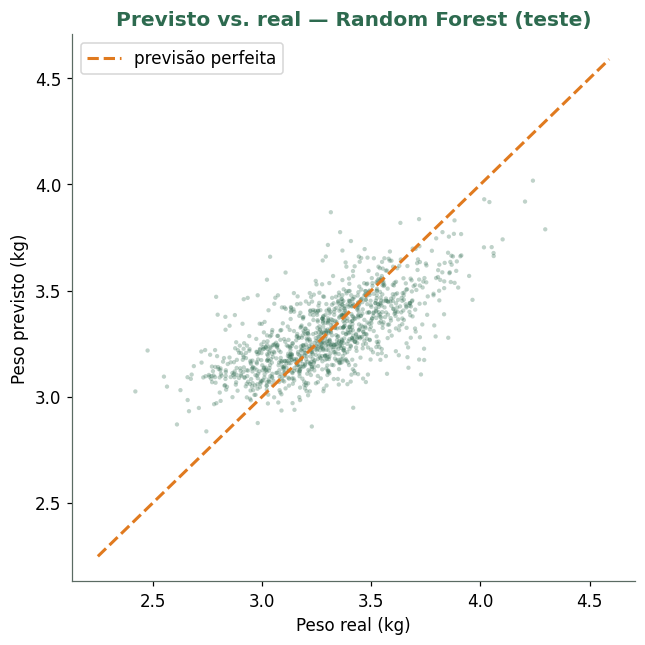

R² teste: 0.485 | RMSE: 0.195 kg | MAE: 0.152 kg


In [10]:
Xtr,Xte,ytr,yte = dados_B
rf = mod_B['Random Forest']
pred = rf.predict(Xte)

plt.figure(figsize=(6,6))
plt.scatter(yte, pred, s=8, alpha=0.3, color=VERDE, edgecolors='none')
lo, hi = y.min(), y.max()
plt.plot([lo,hi],[lo,hi], '--', color=LARANJA, lw=2, label='previsão perfeita')
plt.xlabel('Peso real (kg)'); plt.ylabel('Peso previsto (kg)')
plt.title('Previsto vs. real — Random Forest (teste)', color=VERDE, fontweight='bold')
plt.legend(); plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print('R² teste:', round(r2_score(yte,pred),3),
      '| RMSE:', round(mean_squared_error(yte,pred)**0.5,3), 'kg',
      '| MAE:', round(mean_absolute_error(yte,pred),3), 'kg')

## Slide 9 — O que mais influencia o peso
Importância das variáveis no Random Forest, **agrupada por variável original** (somando as dummies de cada uma).

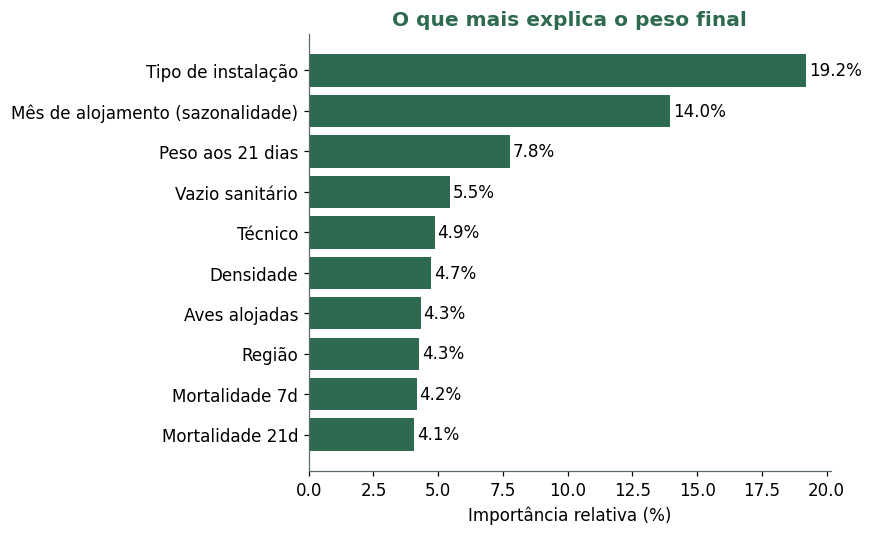

Tipo de instalação                  19.2
Mês de alojamento (sazonalidade)    14.0
Peso aos 21 dias                     7.8
Vazio sanitário                      5.5
Técnico                              4.9
Densidade                            4.7
Aves alojadas                        4.3
Região                               4.3
dtype: float64

In [11]:
rf_full = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_B, y)
imp = pd.Series(rf_full.feature_importances_, index=X_B.columns)

# agrupa as dummies de volta na variável de origem
grupos = {'Tipo de instalação':'Tipo_Instalacao_', 'Mês de alojamento (sazonalidade)':'Mes_',
          'Técnico':'Tecnico_', 'Região':'Regiao_', 'Genética':'Genetica_',
          'Origem do lote':'Origem_', 'Programa nutricional':'Nutricao_'}
nomes = {'Peso21':'Peso aos 21 dias','Peso14':'Peso aos 14 dias','Peso7':'Peso aos 7 dias',
         'Vazio (dias)':'Vazio sanitário','Densidade (aves/m²)':'Densidade','Aves Alojadas':'Aves alojadas',
         'Peso Pintinho (kg)':'Peso do pintinho','Área':'Área do galpão','Num_Galpao':'Nº de galpões',
         '%Mort7':'Mortalidade 7d','%Mort14':'Mortalidade 14d','%Mort21':'Mortalidade 21d'}
agrupada, usadas = {}, set()
for rotulo, pref in grupos.items():
    cols = [c for c in imp.index if c.startswith(pref)]; usadas.update(cols)
    agrupada[rotulo] = imp[cols].sum()
for c in imp.index:
    if c not in usadas: agrupada[nomes.get(c,c)] = imp[c]
agrupada = pd.Series(agrupada).sort_values(ascending=False)

plt.figure(figsize=(8,5))
top = agrupada.head(10)[::-1]
plt.barh(range(len(top)), top.values*100, color=VERDE)
plt.yticks(range(len(top)), top.index)
for i,v in enumerate(top.values*100): plt.text(v+0.1, i, f'{v:.1f}%', va='center')
plt.xlabel('Importância relativa (%)')
plt.title('O que mais explica o peso final', color=VERDE, fontweight='bold')
plt.gca().spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()
(agrupada.head(8)*100).round(1)

## Slide 10 — Sazonalidade
Quando o lote é alojado vale ~280 g por ave: pico em abril, vale em dezembro/janeiro (estresse térmico).

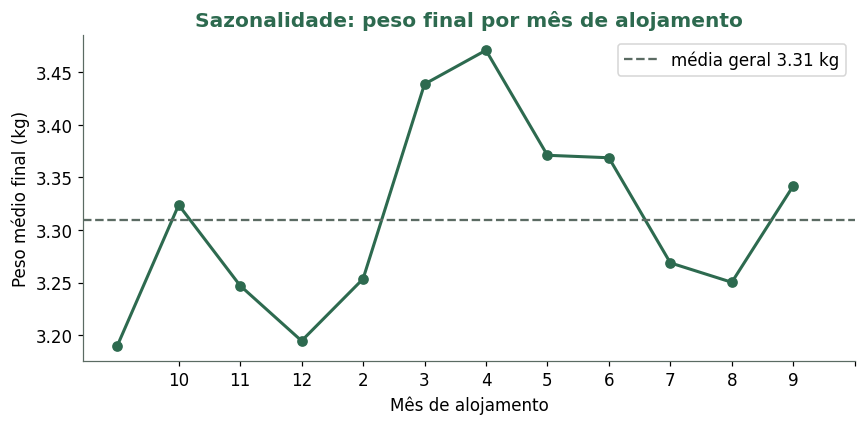

Maior: 3.471 kg (mês 4 ) | Menor: 3.19 kg (mês 1 ) | Diferença: 281 g por ave


In [12]:
media_mes = df_limpo.groupby('Mes')[ALVO].mean()

plt.figure(figsize=(8,4))
plt.plot(media_mes.index, media_mes.values, marker='o', color=VERDE, lw=2)
plt.axhline(y.mean(), ls='--', color=CINZA, label=f'média geral {y.mean():.2f} kg')
plt.xticks(range(1,13)); plt.xlabel('Mês de alojamento'); plt.ylabel('Peso médio final (kg)')
plt.title('Sazonalidade: peso final por mês de alojamento', color=VERDE, fontweight='bold')
plt.legend(); plt.gca().spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

print('Maior:', round(media_mes.max(),3), 'kg (mês', int(media_mes.idxmax()),
      ') | Menor:', round(media_mes.min(),3), 'kg (mês', int(media_mes.idxmin()),
      ') | Diferença:', round((media_mes.max()-media_mes.min())*1000), 'g por ave')

## Slides 11–12 — Conclusões e recomendações

**Resultado:** o melhor modelo (Random Forest) explica cerca de metade da variação do peso (R² ≈ 0,49), com erro médio de ~0,20 kg por lote — cerca de 30% melhor que chutar a média.

**Fatores que mais pesam:** tipo de instalação e sazonalidade (mês de alojamento) dominam; o programa nutricional pesa pouco.

**Recomendações ao cliente:**
1. Planejar o calendário de alojamento (priorizar meses amenos; reforçar climatização no verão/inverno).
2. Priorizar os tipos de instalação que entregam mais peso.
3. Usar a pesagem dos 21 dias como alerta precoce.
4. Profissionalizar a coleta de dados (validação de faixas na digitação).

**Limitação honesta:** ~metade da variação vem de fatores não registrados (clima diário, sanidade, manejo fino). O modelo serve para metas e triagem, não para garantir um lote individual.